# 📊 Exploratory Data Analysis — Criteo Uplift Dataset

Notebook này thực hiện EDA trên bộ dữ liệu **Criteo Uplift** đã được xử lý (đã lấy mẫu cân bằng), sử dụng các hàm tiện ích từ module `src.data.eda`.

**Nội dung chính:**
1. Tổng quan dataset (shape, missing values, duplicate rows)
2. Phân phối Treatment & Target
3. Conversion Rate theo nhóm Treatment / Control
4. Thống kê mô tả các features
5. Phân tích Skewness
6. Correlation Heatmap
7. Histogram phân phối từng feature
8. Phân phối features theo Treatment
9. Box-plots theo Treatment
10. Tổng kết

## 0 · Setup

In [1]:
import sys
from pathlib import Path

# Đảm bảo import được module src từ project root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data.eda import (
    dataset_overview,
    treatment_distribution,
    target_distribution,
    conversion_by_treatment,
    feature_summary,
    feature_skewness,
    get_target_column,
)
from src.data.constants import FEATURE_COLS, TREATMENT_COL

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("Setup OK ✅")

Setup OK ✅


## 1 · Load dữ liệu

In [2]:
TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train.parquet"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file tại {TRAIN_PATH}.\n"
        "Hãy chạy `python -m src.data.make_dataset` trước."
    )

df = pd.read_parquet(TRAIN_PATH)
target_col = get_target_column(df)

print(f"Shape       : {df.shape}")
print(f"Target col  : {target_col}")
df.head()

Shape       : (700000, 13)
Target col  : conversion


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,treatment,conversion
0,12.616365,10.059654,8.857318,4.679882,10.280525,4.115453,0.294443,4.833815,3.943716,13.190056,5.300375,0,0
1,12.616365,10.059654,8.341580,4.679882,10.280525,4.115453,0.294443,4.833815,3.841991,22.570329,5.300375,1,0
2,20.267660,10.059654,8.539668,2.934780,11.029584,4.115453,-3.282109,4.833815,3.882650,24.452088,6.017027,1,0
3,12.616365,10.059654,8.981754,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,1,0
4,12.616365,10.059654,8.640206,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,20.050937,5.300375,1,0


## 2 · Tổng quan Dataset

In [3]:
overview = dataset_overview(df, target_col)
overview.T.rename(columns={0: "value"})

,value
n_rows,700000
n_columns,13
target_col,conversion
treatment_rate,0.850411
target_rate,0.002881
missing_values,0
duplicate_rows,4076


In [4]:
# Kiểm tra kiểu dữ liệu
df.dtypes.to_frame("dtype")

,dtype
f0,float64
f1,float64
f2,float64
f3,float64
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,float64


In [5]:
# Missing values theo cột
missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Không có missing values 🎉")
else:
    display(missing.to_frame("missing_count"))

Không có missing values 🎉


> **📝 Nhận xét - Tổng quan Dataset:**
> - Kích thước tập train là **700,000 dòng** và 13 cột (đủ lớn cho các mô hình Machine Learning).
> - **Không có missing values**, điều này giúp tiết kiệm thời gian tiền xử lý.
> - Có một lượng nhỏ **duplicate rows** (khoảng ~4000 dòng, chiếm ~0.5%). Tỷ lệ này khá nhỏ và có thể là do bản chất dữ liệu (nhiều user chia sẻ cùng hành vi/tính chất).
> - Tất cả các feature đều ở định dạng số hóa (`float64`, `int64`). Không cần thực hiện Encoding.

## 3 · Phân phối Treatment

,group,treatment,n_users,share
0,treatment,1,595288,0.850411
1,control,0,104712,0.149589


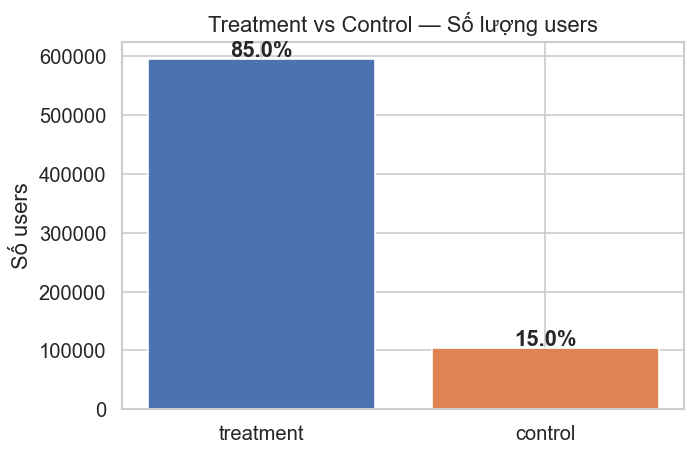

In [6]:
treat_dist = treatment_distribution(df)
display(treat_dist)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#DD8452"]
ax.bar(treat_dist["group"], treat_dist["n_users"], color=colors, edgecolor="white")
for i, row in treat_dist.iterrows():
    ax.text(i, row["n_users"] + len(df)*0.005,
            f"{row['share']:.1%}", ha="center", fontweight="bold")
ax.set_title("Treatment vs Control — Số lượng users")
ax.set_ylabel("Số users")
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Phân phối Treatment:**
> - Nhóm **Treatment** chiếm **~85%**, nhóm **Control** chiếm **~15%**. Tỷ lệ này phản ánh đúng phân phối gốc của Criteo Dataset.
> - Không bị hiện tượng chỉ có 1 nhóm duy nhất nhờ vào việc đã khắc phục vấn đề lấy mẫu của dataset. Việc có cả 2 nhóm này đảm bảo chúng ta có thể tiến hành đánh giá CATE (Conditional Average Treatment Effect) hiệu quả.

## 4 · Phân phối Target

,conversion,n_users,share
0,0,697983,0.997119
1,1,2017,0.002881


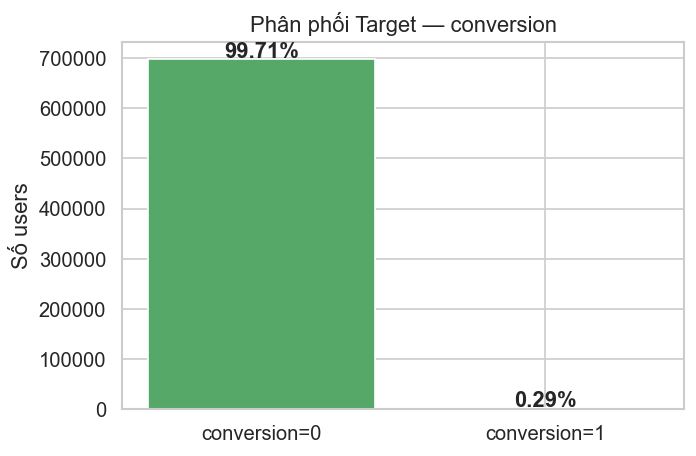

In [7]:
target_dist = target_distribution(df, target_col)
display(target_dist)

fig, ax = plt.subplots(figsize=(6, 4))
labels = [f"{target_col}={v}" for v in target_dist[target_col]]
colors = ["#55A868", "#C44E52"]
ax.bar(labels, target_dist["n_users"], color=colors, edgecolor="white")
for i, row in target_dist.iterrows():
    ax.text(i, row["n_users"] + len(df)*0.005,
            f"{row['share']:.2%}", ha="center", fontweight="bold")
ax.set_title(f"Phân phối Target — {target_col}")
ax.set_ylabel("Số users")
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Phân phối Target:**
> - Bài toán gặp vấn đề **Class Imbalance cực độ**. Nhãn positive (conversion = 1) chỉ chiếm tỷ lệ **~0.29%**.
> - Vì lớp đích rất thiểu số, chúng ta **không nên dùng Accuracy** để đánh giá model, thay vào đó cần dùng các metrics phân hạng Uplift như **AUUC (Area Under Uplift Curve)** hay **Qini Curve**.

## 5 · Conversion Rate theo Treatment Group

,group,treatment,n_users,conversion_rate
0,control,0,104712,0.001824
1,treatment,1,595288,0.003067
2,difference,None,None,0.001243


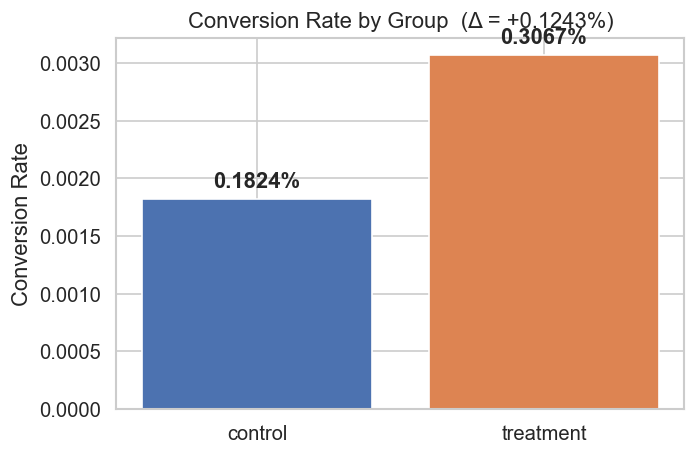

In [8]:
conv_report = conversion_by_treatment(df, target_col)
display(conv_report)

# Chỉ vẽ control vs treatment (bỏ dòng difference)
plot_data = conv_report[conv_report["group"].isin(["control", "treatment"])].copy()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(plot_data["group"], plot_data["conversion_rate"],
              color=colors, edgecolor="white")
for bar, rate in zip(bars, plot_data["conversion_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001,
            f"{rate:.4%}", ha="center", fontweight="bold")

diff_row = conv_report[conv_report["group"] == "difference"]
if not diff_row.empty:
    diff_val = diff_row["conversion_rate"].iloc[0]
    ax.set_title(f"Conversion Rate by Group  (Δ = {diff_val:+.4%})")
else:
    ax.set_title("Conversion Rate by Group")

ax.set_ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Conversion Rate theo Treatment:**
> - Tỷ lệ chuyển đổi ở nhóm **Treatment** cao hơn **Control** (với $\Delta$ xấp xỉ +0.124%).
> - Điều này chứng tỏ **chiến dịch tiếp thị/Treatment có hiệu quả thực tế** làm tăng conversion. Tuy tác động tuyệt đối là nhỏ (0.12%), nhưng ở scale hàng triệu khách hàng, nó sẽ mang lại giá trị đáng kể. Bài toán Uplift modeling hoàn toàn khả thi.

## 6 · Thống kê mô tả các Features

In [9]:
feat_summary = feature_summary(df)
feat_summary.style.format(precision=4)

,feature,count,mean,std,min,25%,50%,75%,max
0,f0,700000.0000,19.6247,5.3786,12.6164,12.6164,21.9256,24.4523,26.7453
1,f1,700000.0000,10.0698,0.1041,10.0597,10.0597,10.0597,10.0597,15.6406
2,f2,700000.0000,8.4467,0.2995,8.2144,8.2144,8.2144,8.7249,9.0520
3,f3,700000.0000,4.1796,1.3353,-6.1349,4.6799,4.6799,4.6799,4.6799
4,f4,700000.0000,10.3391,0.3439,10.2805,10.2805,10.2805,10.2805,19.3288
5,f5,700000.0000,4.0294,0.4290,-8.9122,4.1155,4.1155,4.1155,4.1155
6,f6,700000.0000,-4.1543,4.5774,-29.4676,-6.6993,-2.4111,0.2944,0.2944
7,f7,700000.0000,5.0993,1.2011,4.8338,4.8338,4.8338,4.8338,11.9984
8,f8,700000.0000,3.9335,0.0567,3.6351,3.9108,3.9719,3.9719,3.9719
9,f9,700000.0000,16.0289,7.0242,13.1901,13.1901,13.1901,13.1901,75.2950


> **📝 Nhận xét - Thống kê mô tả:**
> - Các features (từ f0 đến f10) đều là các biến định lượng (continuous variables).
> - Khoảng giá trị của mỗi feature có sự khác biệt (có feature mang giá trị âm, có feature trị số lên tới hàng chục), có thể cần cân nhắc Scaling (Standardization/Normalization) nếu dùng các model như Logistic Regression / SVM. Tuy nhiên, nếu dùng Tree-based models (XGBoost/LightGBM) thì việc scaling là không bắt buộc.

## 7 · Phân tích Skewness

,feature,skewness,abs_skewness
1,f1,14.3727,14.3727
4,f4,8.8524,8.8524
5,f5,-7.1013,7.1013
10,f10,5.2603,5.2603
7,f7,4.5515,4.5515
3,f3,-3.1907,3.1907
9,f9,2.8253,2.8253
8,f8,-1.5997,1.5997
6,f6,-1.1371,1.1371
2,f2,0.8060,0.8060


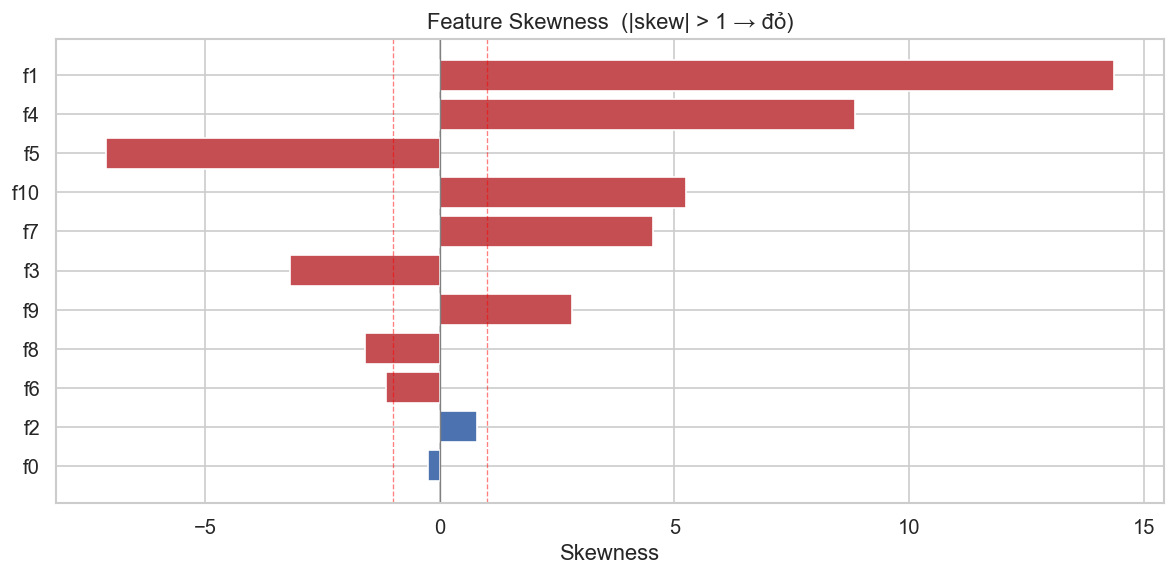

In [10]:
skew_report = feature_skewness(df)
display(skew_report.style.format(precision=4))

fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#C44E52" if abs(s) > 1 else "#4C72B0" for s in skew_report["skewness"]]
ax.barh(skew_report["feature"], skew_report["skewness"], color=palette, edgecolor="white")
ax.axvline(0, color="grey", linewidth=0.8)
ax.axvline(-1, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(1, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Skewness")
ax.set_title("Feature Skewness  (|skew| > 1 → đỏ)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Độ lệch (Skewness):**
> - Phần lớn các features đều bị lệch rất nặng (|skewness| > 1).
> - Đặc biệt các features như `f1` và `f4` lệch phải cực mạnh, trong khi `f5` và `f3` bị lệch trái.
> - Các phân phối bất đối xứng này cho thấy dữ liệu chứa rất nhiều **outliers** hoặc có tập trung giá trị đặc biệt. Nếu dùng model tuyến tính, ta cần cân nhắc sử dụng các kỹ thuật như Log-transform hay Power-transform (Yeo-Johnson).

## 8 · Correlation Heatmap

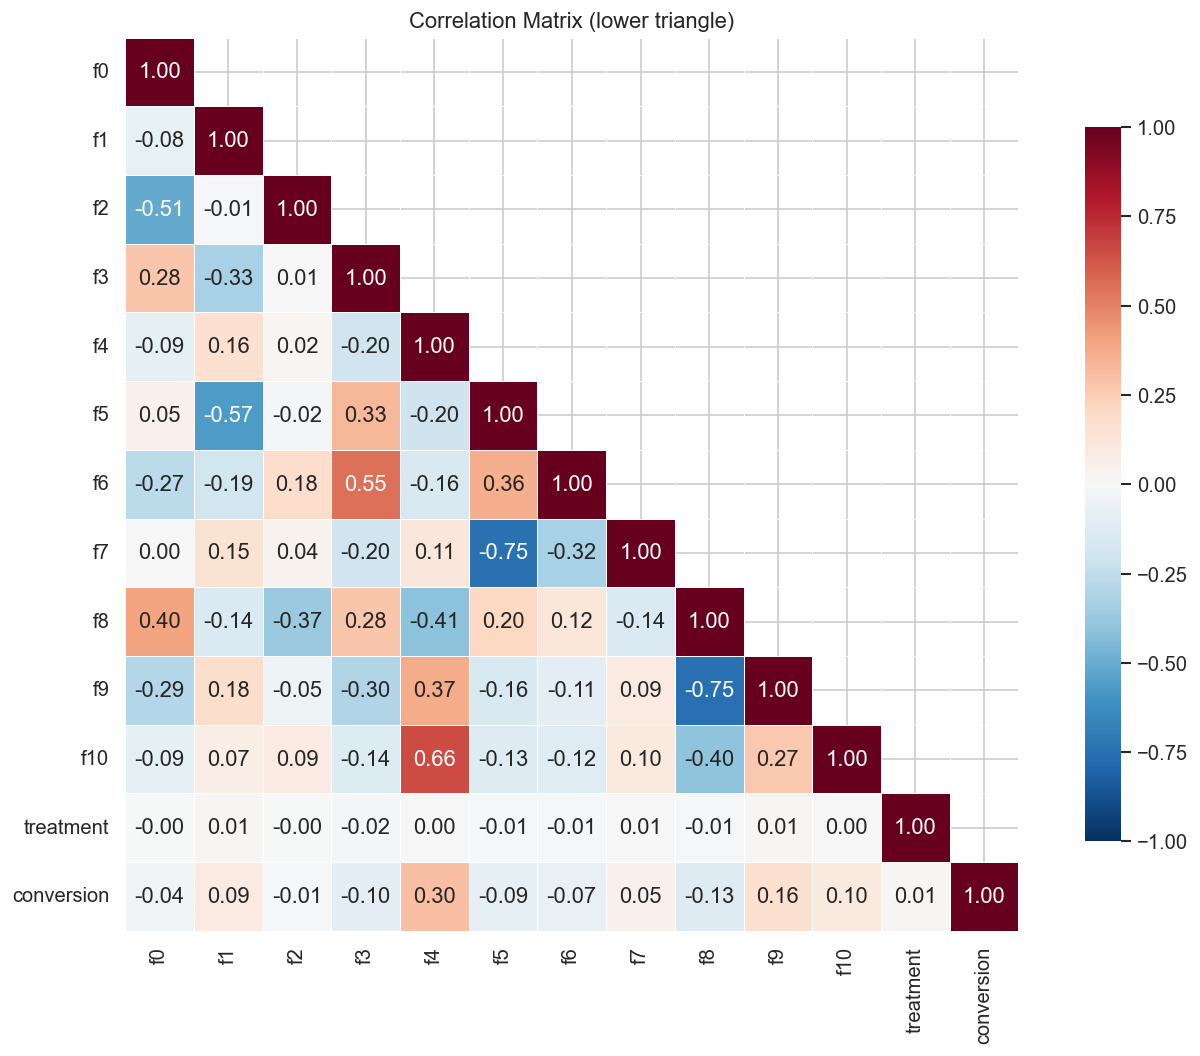

In [11]:
corr = df[FEATURE_COLS + [TREATMENT_COL, target_col]].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Tương quan (Correlation):**
> - **Giữa các features**: Có sự hiện diện của tính đa cộng tuyến (multicollinearity) mạnh giữa một số nhóm biến như `(f5, f7)`, `(f8, f9)`, `(f4, f8)`, v.v. (tương quan > 0.6 hoặc < -0.6).
> - **Giữa features và Target**: Hầu hết độ tương quan tuyến tính là rất thấp. Đáng chú ý nhất có `f4` (0.30) và `f9` (0.16). Sự kém tương quan tuyến tính gợi ý cần đến sức mạnh của các mô hình Non-linear (như Gradient Boosting) để phát hiện ra quy luật thật sự.

## 9 · Histogram phân phối từng Feature

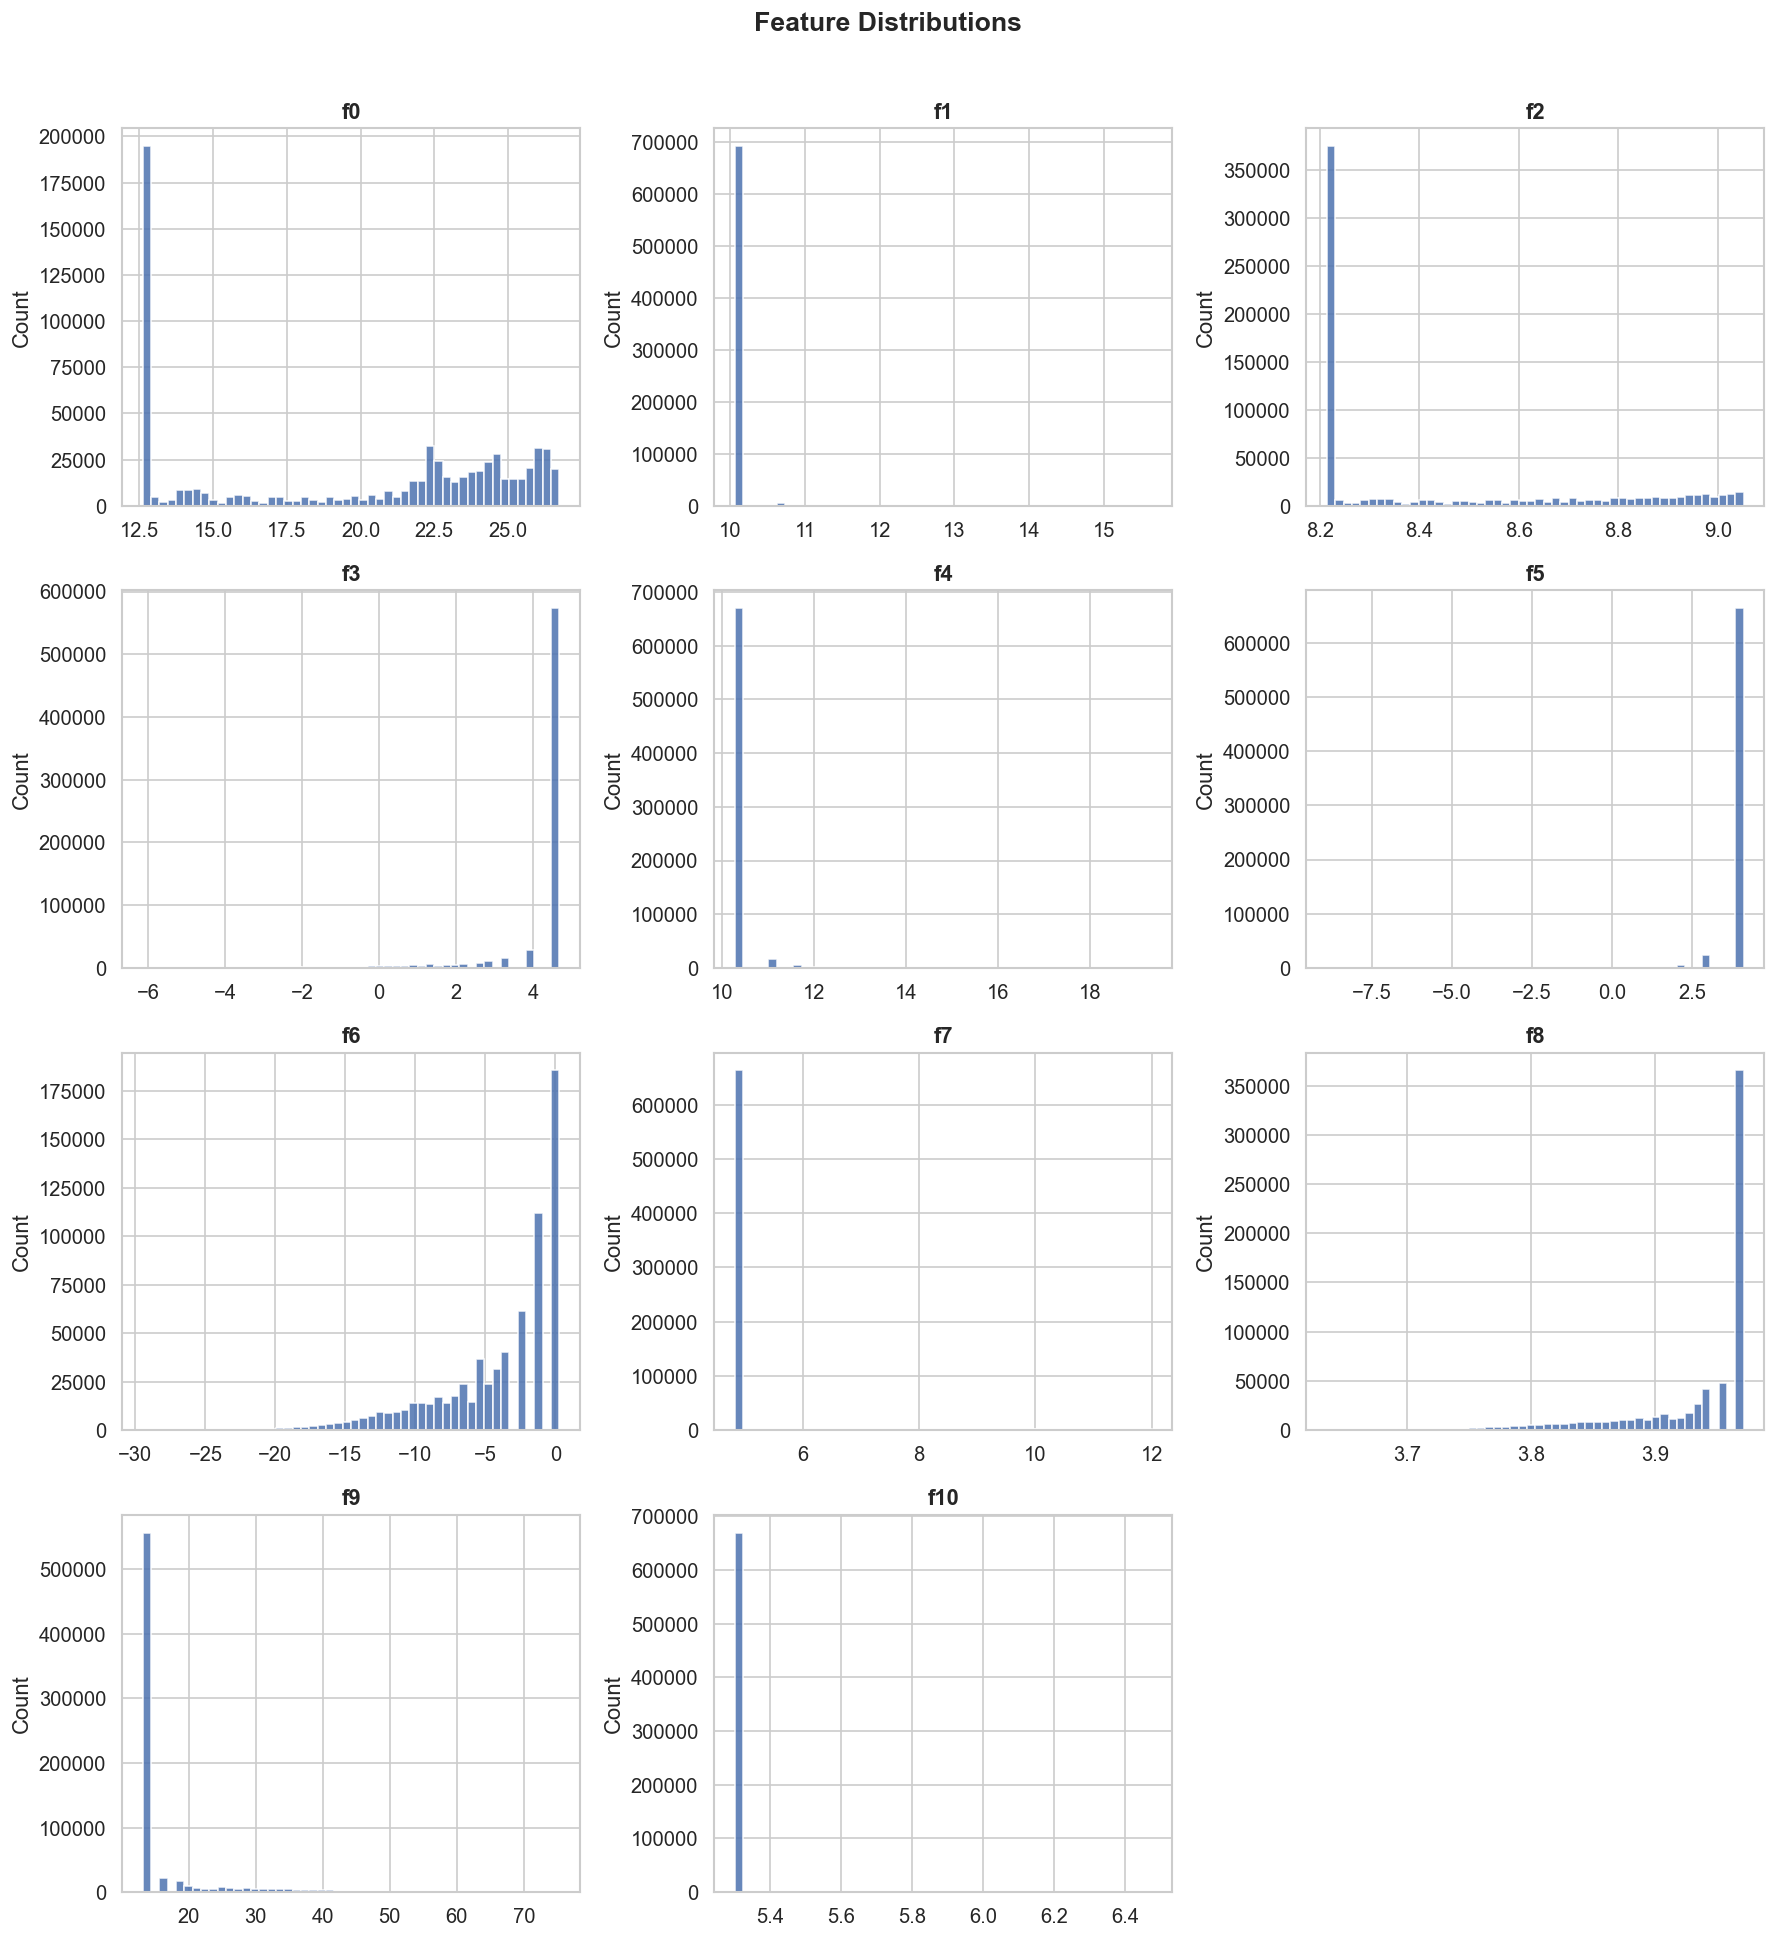

In [12]:
n_features = len(FEATURE_COLS)
ncols = 3
nrows = (n_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(df[feat].dropna(), bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Ẩn subplot thừa
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Histogram:**
> - Các biểu đồ Histogram phản ánh lại nhận định về Skewness bên trên. Dễ nhận thấy đa số các biến có phân phối nhọn và dồn về 1 phía (Spiky distributions), minh chứng rõ rệt cho việc nhiều tập user chia sẻ cùng một giá trị đặc trưng chung, đồng thời có lượng dài (long tail) ở hai phía.

## 10 · Feature Distribution theo Treatment Group

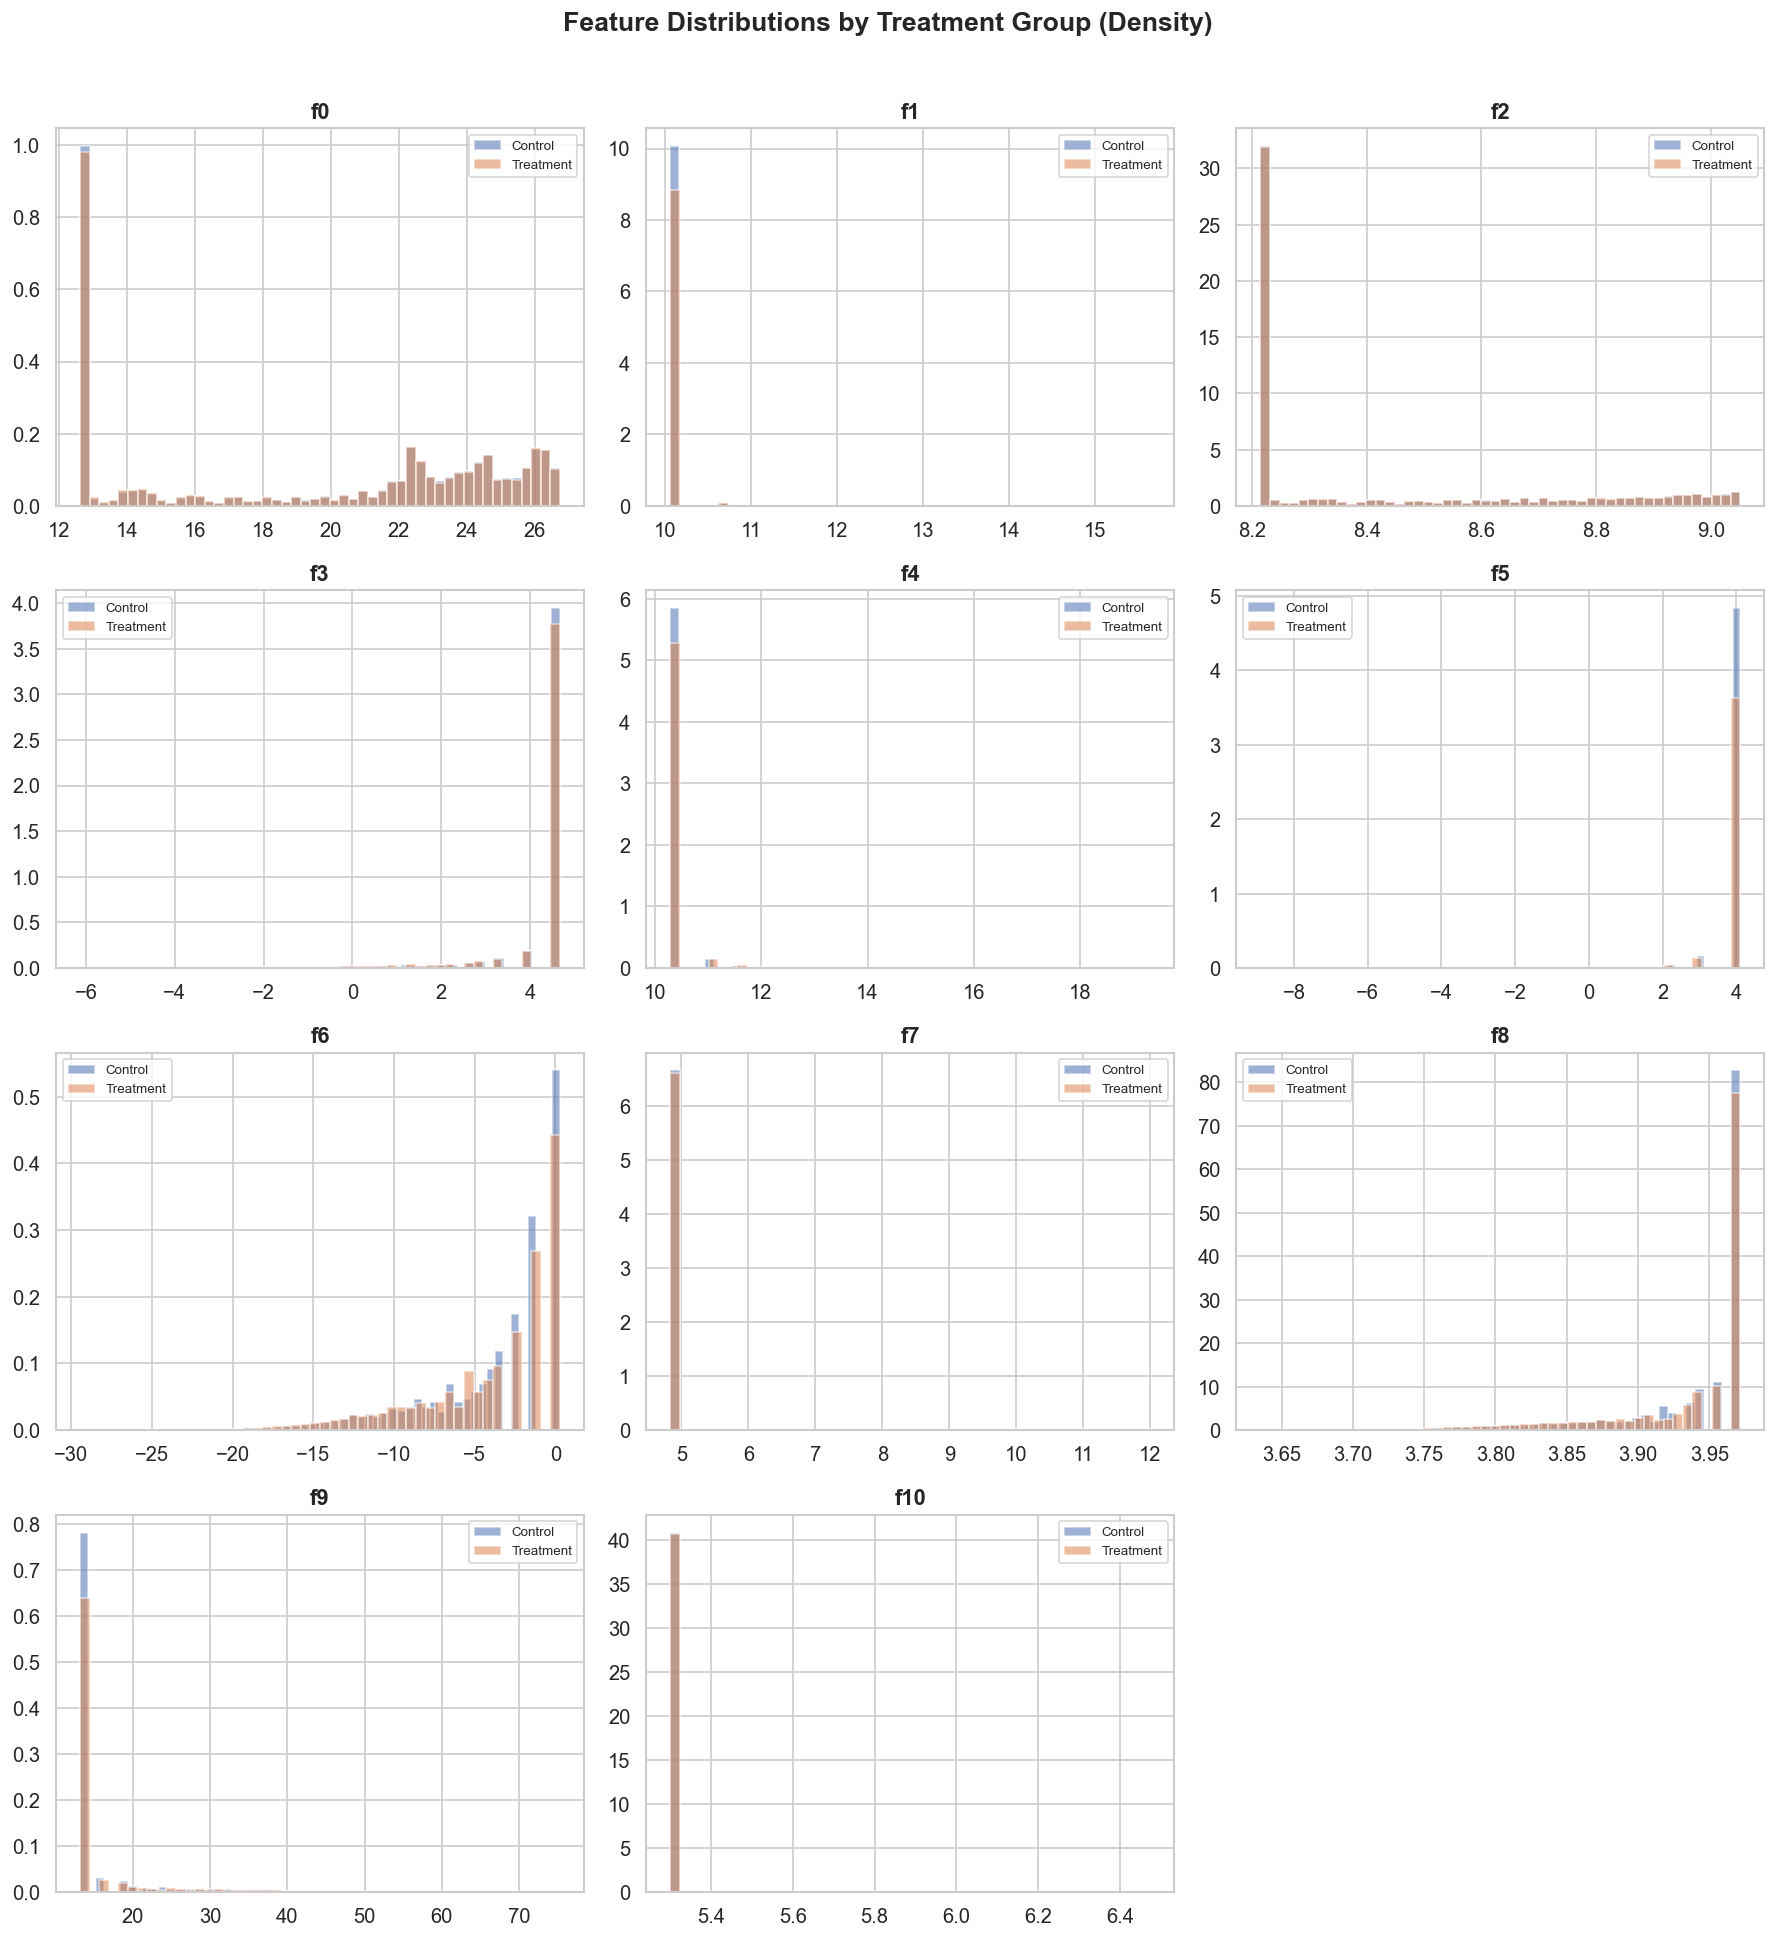

In [13]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for grp, color, label in [(0, "#4C72B0", "Control"), (1, "#DD8452", "Treatment")]:
        subset = df.loc[df[TREATMENT_COL] == grp, feat].dropna()
        ax.hist(subset, bins=50, alpha=0.55, color=color, label=label, edgecolor="white", density=True)
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=8)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Treatment Group (Density)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Feature Distribution theo Treatment:**
> - Hình dạng phân phối mật độ (Density) của từng feature ở cả 2 nhóm Treatment và Control gần như đồng nhất và chồng lên nhau. 
> - Điều này cực kỳ quan trọng và tuyệt vời: Nó xác nhận rằng **phép chia nhóm ngẫu nhiên (Randomized Controlled Trial - RCT) của tập dữ liệu đã hoạt động chuẩn xác**, không có sai lệch (bias) về đặc trưng giữa nhóm người nhận chiến dịch so với nhóm người không nhận.

## 11 · Box-plot Features

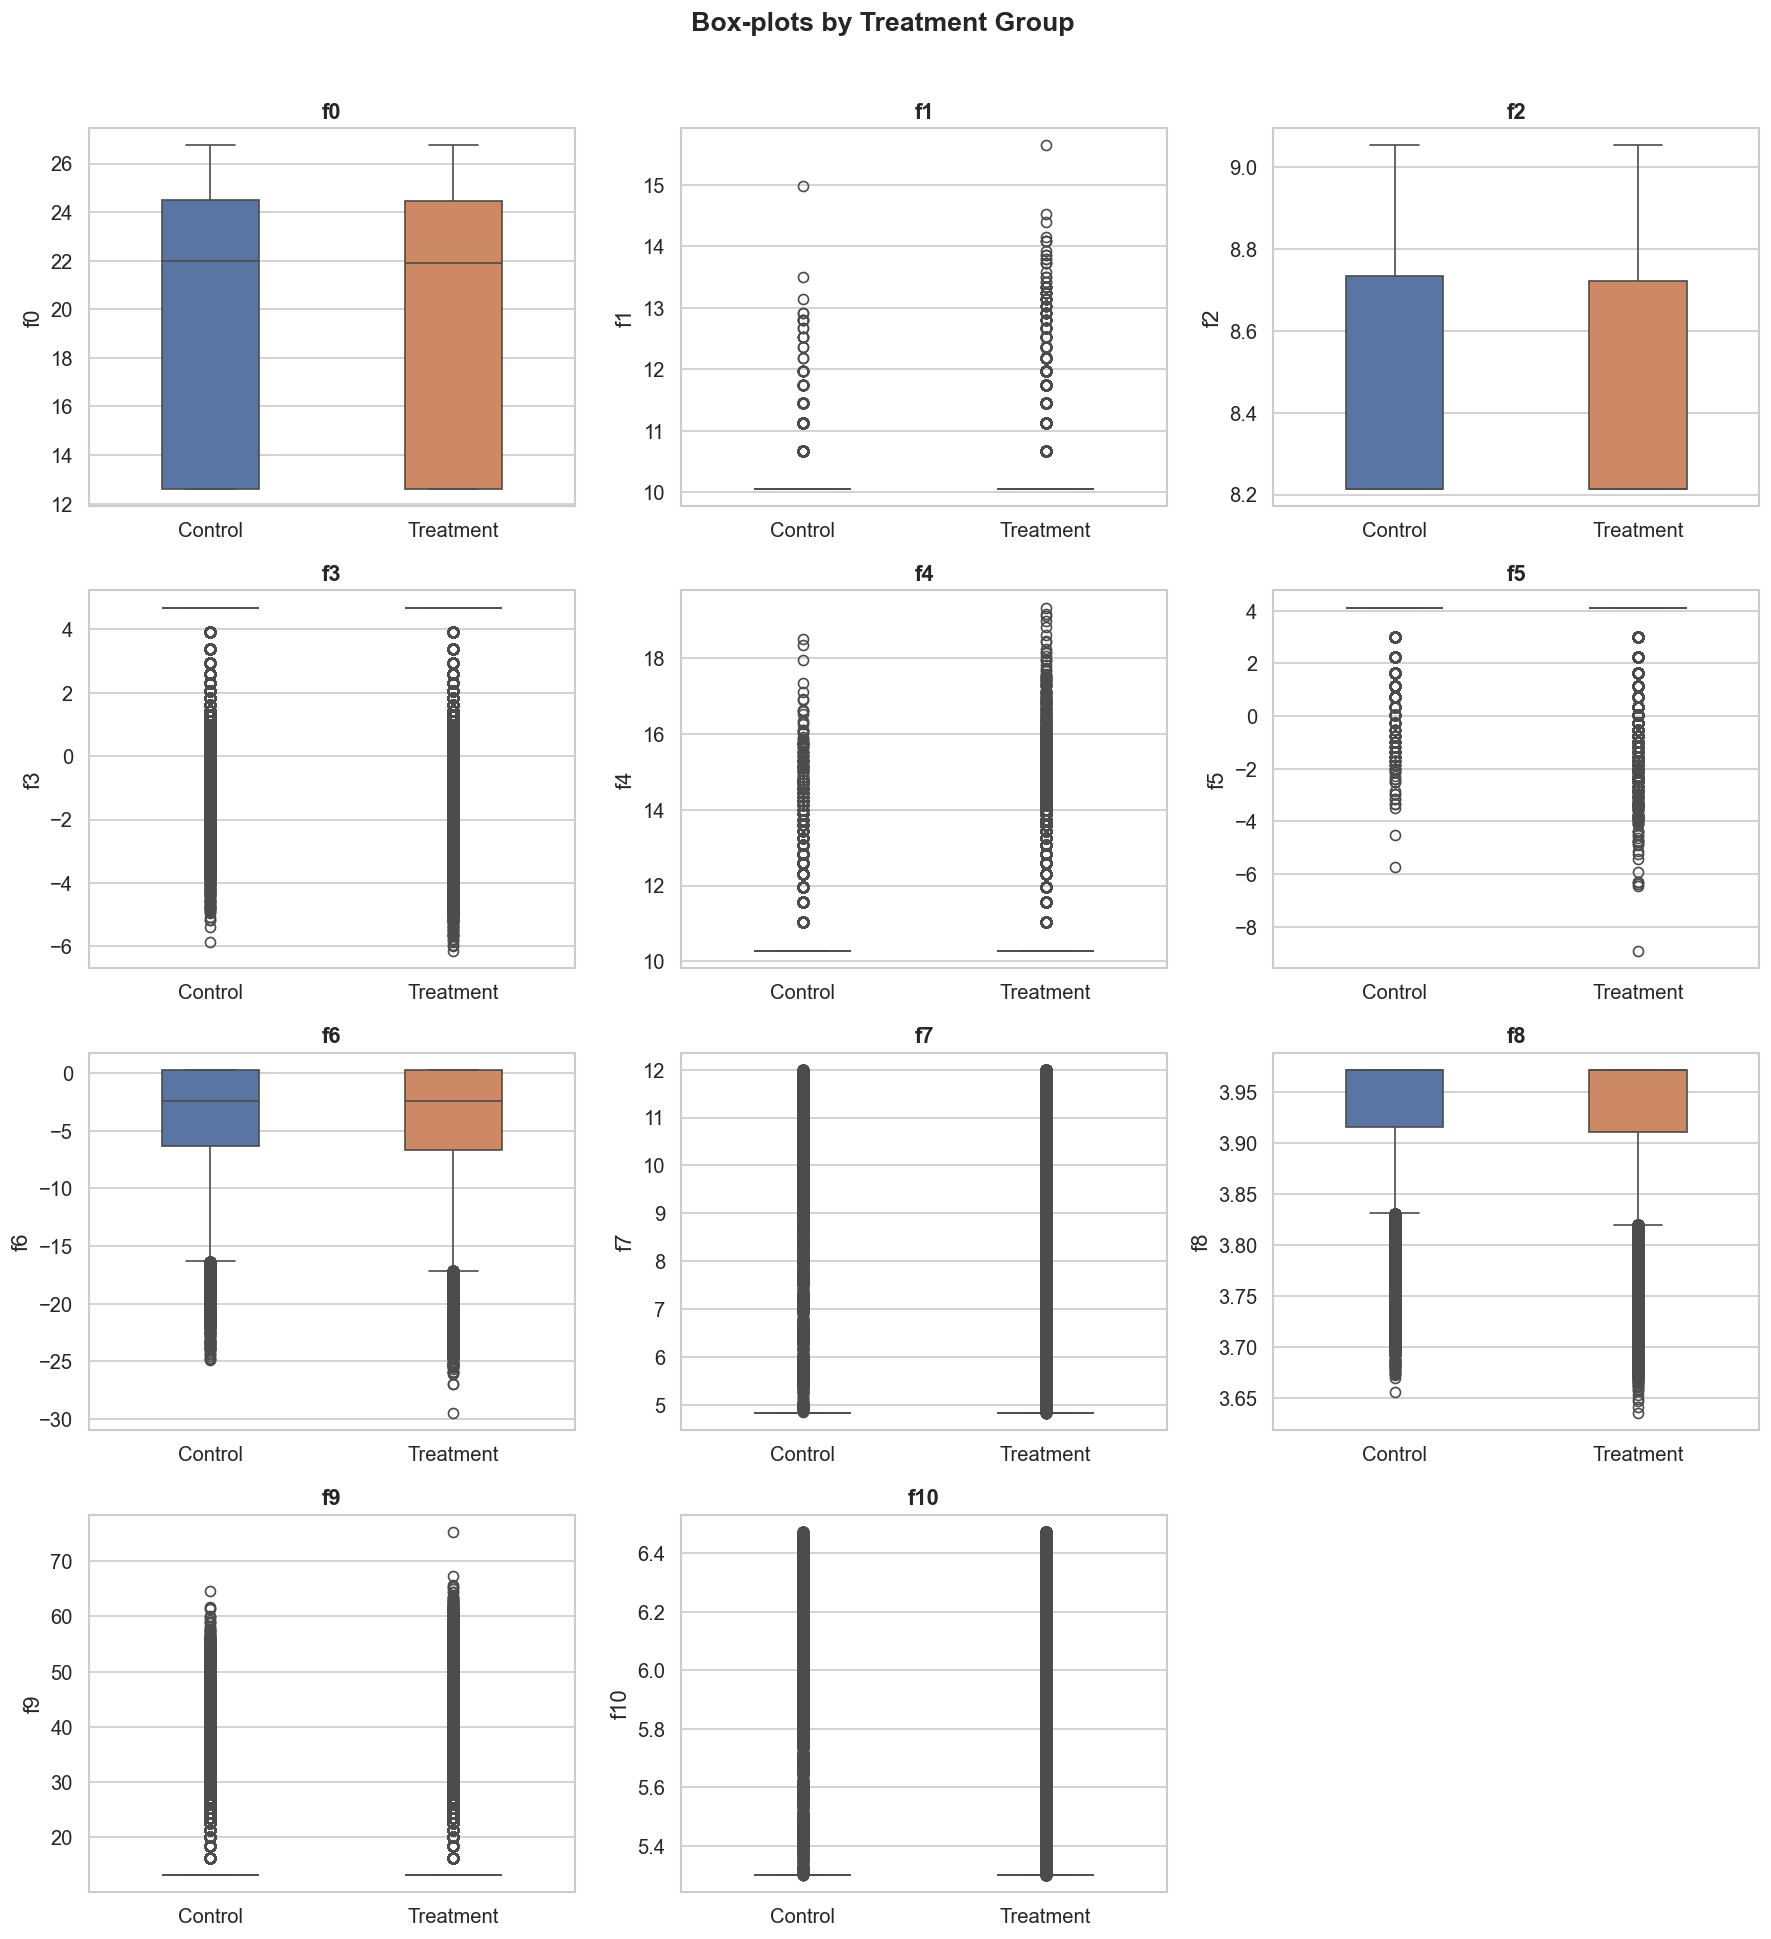

In [14]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    sns.boxplot(data=df, x=TREATMENT_COL, y=feat, ax=ax,
                palette=["#4C72B0", "#DD8452"], width=0.4)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(["Control", "Treatment"])

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Box-plots by Treatment Group", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> **📝 Nhận xét - Box-plots:**
> - Tiếp tục khẳng định lại tính **cân bằng tự nhiên** giữa phân phối của 2 tập.
> - Các râu (whiskers) kéo khá xa ở nhiều features, chứng tỏ sự tồn tại của lượng lớn outliers cần lưu ý trong quy trình model training sắp tới.

## 12 · Tóm tắt & Tổng kết Đánh giá

| Khía cạnh | Tình trạng | Đánh giá & Đề xuất Hành động (Next Steps) |
|---|---|---|
| **Chất lượng dữ liệu** | Rất sạch | Không chứa missing values, data types đã chuẩn. Có lượng nhỏ records bị lặp (duplicate) nhưng không đáng kể và không làm hỏng tính chất phân phối. |
| **Phân bổ Treatment/Control** | 85% / 15% | Đã được lấy mẫu chéo chính xác từ dataset gốc. Phân phối đặc trưng features (Histogram / Boxplot) giữa 2 nhóm tương đồng, chứng tỏ thí nghiệm thiết kế chuẩn RCT (Randomized Controlled Trial). |
| **Conversion (Tác động)** | + 0.12% | Treatment mang lại mức tăng conversion so với Control. Bài toán Uplift modeling hoàn toàn khả thi. |
| **Target Imbalance** | 99.7% / 0.3% | Target cực kỳ mất cân bằng. Cần cân nhắc Stratified Sampling trong Validation. **Không dùng Accuracy** làm metric mà bắt buộc sử dụng **AUUC** (Area Under Uplift Curve) và **Qini** để đo lường. |
| **Phân phối Features** | Skewed mạnh | Dữ liệu bị lệch (Skew) nặng và có Outliers. Cân nhắc dùng họ Tree-based Algorithms (XGBoost, LightGBM) vì chúng xử lý rất tốt các tập dữ liệu không chuẩn hóa mà không cần phải Transform. |
| **Tính đa cộng tuyến** | Trung bình đến Cao | Có tồn tại Multi-collinearity. Một lần nữa, Tree-based Models sẽ ưu việt hơn Linear Models trong trường hợp này. |

**Kết luận chung:**
Bộ dữ liệu Criteo Uplift hiện tại đã **sẵn sàng cho bước Model Training**. Vấn đề nghiêm trọng về lệch mẫu (chỉ có nhóm Treatment) trước đó đã được loại bỏ. Trọng tâm của bài toán hiện tại sẽ đặt vào việc chọn thuật toán phù hợp (VD: Meta-learners, Tree-based models) để giải quyết đặc thù dữ liệu Skew và Class Imbalance của Uplift Modeling.